# Paper figures

Plotting notebook for the DH Tau B CRIRES+ paper figures, in A&A journal style (serif fonts, inward ticks, compact sizing for single/double-column figures).

## 0. Style setup (A&A journal format)

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from scipy.optimize import curve_fit

from excalibuhr.data import DETECTOR

# A&A-like rcParams: serif fonts, inward ticks on all sides, minor ticks on,
# and a font size that stays legible once the figure is shrunk to a
# single (3.5 in) or double (7.1 in) column width in the printed journal.
plt.rcParams.update({
    'font.size': 9,
    'font.family': 'serif',
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 0.6,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth': 1.0,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,   # embed real fonts (not Type-3) for journal submission
    'ps.fonttype': 42,
})

# Single- and double-column widths for A&A (inches)
AA_COL_WIDTH = 3.54
AA_PAGE_WIDTH = 7.24

FIG_DIR = '/data2/peng/Recipe_DH_Tau_B/Reminisce/paper_figures'
import os
os.makedirs(FIG_DIR, exist_ok=True)

## Figure 1 — Companion trace (raw) with PSF fit

Night 2 (2023-01-01), order index 1 (physical order 24, i.e. "order-2" of the
7 orders 23-29), detector 0, nod position A. Left panel: the raw, rectified
2D spectrum (`Extr2D`, wavelength-calibrated, no telluric/bad-pixel masking)
zoomed to the spatial window used for the companion fit -- showing the
actual trace being fitted, not a post-subtraction product. Right panel: the
data profile, the stellar-halo (polynomial) fit, the halo+PSF (polynomial +
Moffat) model, and the halo-subtracted residual, from the
`fit_stellar_halo_and_subtract` routine in `cooking_subtraction_0101.ipynb`
(method 5.A.2), computed on the masked/corrected version of the same
(detector, order) pair and sharing the spatial-pixel axis with the left panel.

In [2]:
# Night 2 = 2023-01-01 (Night 1 = 2022-12-31; see recording_recipe.md)
night = '2023-01-01'
workpath = f'/data2/peng/{night}'

det, order = 0, 1   # detector 0; order index 1 -> physical order 24 ("order-2")

extr2d_A = DETECTOR(filename=f'{workpath}/out/combined/Extr2D_PRIMARY__COMBINED_VDHTauA+Bcenter_K2166_NOD_A.npz')
flux2d_A = np.array(extr2d_A.flux)   # (3 det, 7 order, 121 spatial, 2048 spectral), rectified & wavelength-calibrated

wave_cal = fits.open(f'{workpath}/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
wave_data = wave_cal[1].data          # (3 det, 7 order, 2048), nm

print('flux2d_A shape:', flux2d_A.shape)
print(f'order index {order} wavelength range: {wave_data[det, order].min():.2f}-{wave_data[det, order].max():.2f} nm')

flux2d_A shape: (3, 7, 121, 2048)
order index 1 wavelength range: 2321.59-2337.56 nm


### 1.2 Correction: telluric transmission + bad-pixel masking

Same masking step as `cooking_subtraction_0101.ipynb` (`Spectra_fitting.Mask_spec`,
section 1.1): pixels with molecfit transmission &le; 0.7, or that are &gt;3&sigma;
outliers along the spectral axis, are flagged as NaN.

In [3]:
def interpolate_to_wave_solution(wave_model, flux_model, wave_solution):
    """Interpolate a 1D model spectrum onto the (det, order, pix) wavelength grid."""
    spec_interp_matrix = np.zeros(shape=wave_solution.shape)
    for d in range(wave_solution.shape[0]):
        for o in range(wave_solution.shape[1]):
            wave_cut = wave_solution[d, o]
            model_mask = (wave_model >= wave_cut.min()) & (wave_model <= wave_cut.max())
            spec_interp_matrix[d, o] = np.interp(wave_cut, wave_model[model_mask], flux_model[model_mask])
    return spec_interp_matrix


def mask_spec(spectra, transmission_matrix, atm_threshold, sigma_threshold):
    """Flag telluric- and outlier-contaminated pixels as NaN (Spectra_fitting.Mask_spec)."""
    spectra = spectra.copy()
    nDet, nOrder, n_spatial, _ = spectra.shape
    for iDet in range(nDet):
        for iOrder in range(nOrder):
            low_atmo_mask = transmission_matrix[iDet, iOrder] <= atm_threshold
            mean_flux = np.nanmean(spectra[iDet, iOrder], axis=1)
            std_flux = np.nanstd(spectra[iDet, iOrder], axis=1)
            for isp in range(n_spatial):
                row = spectra[iDet, iOrder, isp]
                bad_pixel_mask = np.abs(row - mean_flux[isp]) > sigma_threshold * (std_flux[isp] + 1e-12)
                row[bad_pixel_mask | low_atmo_mask] = np.nan
    return spectra


trans = fits.open(f'{workpath}/chi_tau/{night}/out/molecfit/TELLURIC_DATA.fits')
trans_data = trans[1].data
trans_matrix = interpolate_to_wave_solution(trans_data['lambda'] * 1e3, trans_data['mtrans'], wave_data)

spectra_masked_A = mask_spec(flux2d_A, trans_matrix, atm_threshold=0.7, sigma_threshold=3)

n_spa = 40   # spatial rows kept for the companion-region fit (as in cooking_subtraction_0101.ipynb)

# Masked/corrected spectrum -- used for the PSF fit below (telluric lines and bad
# pixels would otherwise bias the polynomial-halo + Moffat fit).
spec2d = spectra_masked_A[det, order, 0:n_spa, :]

# Untouched Extr2D flux for the same (det, order) -- used for the left-panel display,
# so the figure shows the actual raw trace rather than the NaN-masked version.
spec2d_raw = flux2d_A[det, order, 0:n_spa, :]

print(f'masked fraction: {np.isnan(spec2d).mean():.2%}')

masked fraction: 6.68%


### 1.3 PSF fit: stellar halo (polynomial) + companion (Moffat)

Ported from method 5.A.2 (`fit_stellar_halo_and_subtract`) in
`cooking_subtraction_0101.ipynb`: a polynomial fit to the halo in the
companion-free "sky" rows, then a Moffat fit to the residual near the
companion, giving its centroid and FWHM.

In [4]:
def fit_stellar_halo_and_subtract(spec2d, x0_planet=19, fwhm_guess=8.0, beta_init=3.0,
                                   sky_rows=None, poly_deg=3):
    """Method 5.A.2 from cooking_subtraction_0101.ipynb: polyfit halo + Moffat residual fit."""
    n_spatial, n_wave = spec2d.shape
    x = np.arange(n_spatial, dtype=float)
    x_norm = x / max(float(np.ptp(x)), 1.0)

    sky_mask = np.zeros(n_spatial, dtype=bool)
    for r in sky_rows:
        if 0 <= r < n_spatial:
            sky_mask[r] = True

    spec_arr = np.nan_to_num(spec2d, nan=0.0)
    profile_mean = np.mean(spec_arr, axis=1)
    profile_total = max(float(np.nansum(np.abs(profile_mean))), 1e-30)
    profile_norm = profile_mean / profile_total

    poly_c = np.polyfit(x_norm[sky_mask], profile_norm[sky_mask], deg=poly_deg)
    poly_norm_fit = np.polyval(poly_c, x_norm)

    residual = profile_norm - poly_norm_fit
    lo_p, hi_p = max(0, x0_planet - 10), min(n_spatial, x0_planet + 10)
    x_win, res_win = x[lo_p:hi_p], residual[lo_p:hi_p]

    x0f_p = float(x_win[np.nanargmax(res_win)]) if res_win.size and np.nanmax(res_win) > 0 else float(x0_planet)
    alpha0 = fwhm_guess / (2.0 * np.sqrt(2.0**(1.0 / beta_init) - 1.0))
    A0 = max(float(residual[int(np.clip(x0f_p, 0, n_spatial - 1))]), 1e-12)
    A_upper = max(A0 * 10.0, float(np.nanmax(np.abs(profile_norm))), 1e-4)

    popt_m, _ = curve_fit(
        lambda xx, A_, a_, b_, x0_: A_ * (1.0 + ((xx - x0_) / a_)**2)**(-b_),
        x_win, res_win, p0=[A0, alpha0, beta_init, x0f_p],
        bounds=([0., 1e-6, 0.5, float(lo_p)], [A_upper, np.inf, 50., float(hi_p - 1)]),
        maxfev=20000)
    A_p, alpha_p, beta_p, x0f_p = popt_m
    fwhm = 2.0 * alpha_p * np.sqrt(2.0**(1.0 / beta_p) - 1.0)

    fit_params = {'x0': x0f_p, 'fwhm': fwhm, 'alpha': alpha_p, 'beta': beta_p,
                  'A_norm': A_p, 'poly_c_norm': poly_c, 'profile_total': profile_total}

    V_sky = np.vander(x_norm[sky_mask], poly_deg + 1)
    V_all = np.vander(x_norm, poly_deg + 1)
    C_cols, _, _, _ = np.linalg.lstsq(V_sky, spec_arr[sky_mask, :], rcond=None)
    halo_model = V_all @ C_cols

    clean_phys = spec_arr - halo_model
    clean_phys[~np.isfinite(spec2d)] = np.nan

    return clean_phys, fit_params, profile_mean


sky_rows_A = list(range(0, 10)) + list(range(27, n_spa))   # rows free of companion signal
clean_phys, fit_params, profile_mean = fit_stellar_halo_and_subtract(
    spec2d, x0_planet=19, fwhm_guess=8.0, sky_rows=sky_rows_A, poly_deg=3)

# Reconstruct the halo and halo+PSF models in physical units [e-/s] for plotting
x_arr = np.arange(n_spa, dtype=float)
x_nrm = x_arr / max(float(np.ptp(x_arr)), 1.0)
ptot = fit_params['profile_total']
poly_rec = np.polyval(fit_params['poly_c_norm'], x_nrm) * ptot
moff_rec = (fit_params['A_norm']
            * (1.0 + ((x_arr - fit_params['x0']) / fit_params['alpha'])**2) ** (-fit_params['beta'])) * ptot

print(f"companion centroid x0 = {fit_params['x0']:.2f} px, FWHM = {fit_params['fwhm']:.2f} px")

companion centroid x0 = 18.19 px, FWHM = 6.49 px


### 1.4 Figure: raw companion trace (left) + PSF fit (right)

/var/tmp/peng/ipykernel_1160852/4278552000.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.6)


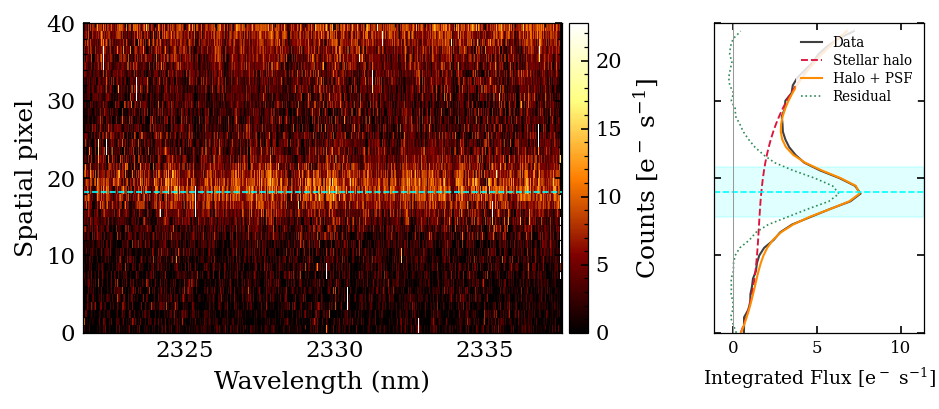

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

wave = wave_data[det, order]   # nm, monotonically increasing with pixel index
y = np.arange(n_spa)
residual_profile = np.nanmean(clean_phys, axis=1)

x0, fwhm = fit_params['x0'], fit_params['fwhm']
vmin, vmax = ZScaleInterval(contrast=0.25).get_limits(spec2d_raw[np.isfinite(spec2d_raw)])
vmin = max(vmin, 0.0)

fig, (ax_trace, ax_psf) = plt.subplots(
    1, 2, figsize=(AA_PAGE_WIDTH, 0.37 * AA_PAGE_WIDTH),
    gridspec_kw={'width_ratios': [2.4, 1.0], 'wspace': 0.35})

# --- Left: raw (unmasked) rectified Extr2D trace, same (det, order) as the fit ---
im = ax_trace.imshow(spec2d_raw, aspect='auto', origin='lower', vmin=vmin, vmax=vmax,
                      extent=[wave.min(), wave.max(), 0, n_spa], cmap='afmhot')
ax_trace.axhline(x0, color='cyan', ls='--', lw=0.8)
ax_trace.set_xlabel('Wavelength (nm)', fontsize=12)
ax_trace.set_ylabel('Spatial pixel', fontsize=12)
ax_trace.tick_params(axis='both', labelsize=11)

# Attach the colorbar to ax_trace's own space so it can't encroach on ax_psf
divider = make_axes_locatable(ax_trace)
cax = divider.append_axes('right', size='4%', pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'Counts [e$^-$ s$^{-1}$]', fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.locator = mticker.MaxNLocator(nbins=5)
cbar.update_ticks()

# --- Right: PSF fit diagnostic (from the masked/corrected spectrum), sharing the
#     spatial-pixel axis -- and hence the same order/detector wavelength range --
#     with the left panel ---
ax_psf.plot(profile_mean, y, color='0.25', label='Data')
ax_psf.plot(poly_rec, y, color='crimson', ls='--', lw=0.9, label='Stellar halo')
ax_psf.plot(poly_rec + moff_rec, y, color='darkorange', label='Halo + PSF')
ax_psf.plot(residual_profile, y, color='seagreen', ls=':', lw=0.8, label='Residual')

ax_psf.axhline(x0, color='cyan', ls='--', lw=0.8)
ax_psf.axhspan(x0 - fwhm / 2, x0 + fwhm / 2, color='cyan', alpha=0.12)
ax_psf.axvline(0, color='0.6', lw=0.5)
ax_psf.set_ylim(0, n_spa - 1)
pmax = np.nanmax(profile_mean)
ax_psf.set_xlim(-0.15 * pmax, 1.5 * pmax)   # keep the panel on the companion peak,
                                              # clear of the polynomial's unconstrained edge tails
ax_psf.set_xlabel(r'Integrated Flux [e$^-$ s$^{-1}$]')

# Match the right panel's y-axis ticks to the left panel's, and drop the minor
# ticks -- the right panel doesn't need the same tick density as the image.
ax_psf.set_yticks(ax_trace.get_yticks())
ax_psf.minorticks_off()
ax_psf.tick_params(labelleft=False)
ax_psf.legend(loc='upper right', frameon=True, framealpha=0.85, edgecolor='none',
              fontsize=6.5, handlelength=1.5, borderpad=0.4, labelspacing=0.3)

fig.tight_layout(pad=0.6)
fig.savefig(f'{FIG_DIR}/fig_companion_trace_psf.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_companion_trace_psf.png', bbox_inches='tight')
plt.show()

## Figure 2 — Absolute flux calibration (Night 2)

Night 2 (2023-01-01) absolute flux-calibrated CRIRES+ spectrum against the
SINFONI reference spectrum and the 2MASS $K_s$ photometric anchor, same
calibration as `cooking_combine_spectra_0101.ipynb` (section 2). Bottom panel:
the per-detector SINFONI/CRIRES+ scale factor actually applied (smooth curve),
with the underlying per-pixel ratio (scatter) behind it. Detector 2's reddest
chip (order 0, ~2425-2472 nm) has only 5.8% pixel-level SINFONI overlap
(below the 20% coverage cut) and is not fit directly -- its scale is frozen
flat at the last well-covered wavelength to avoid a divergent cubic
extrapolation, per `observation_data_reduction_notes.md` §11.

/var/tmp/peng/ipykernel_1160852/695124351.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.4)


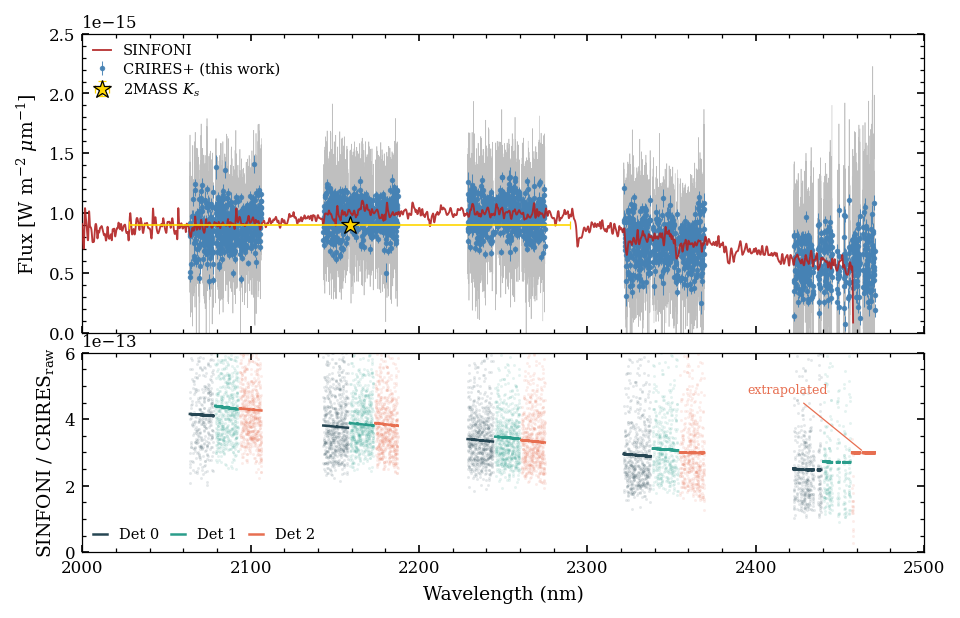

In [6]:
from scipy.interpolate import interp1d

# --- Load the absolute flux-calibrated Night 2 spectrum (cooking_combine_spectra_0101.ipynb, sec. 2) ---
flux_cal = np.load(f'{workpath}/extracted_spectra_combined_flux_cal.npy')       # (3, 5, 2048), W m-2 um-1
flux_cal_err = np.load(f'{workpath}/extracted_spectra_combined_err_flux_cal.npy')
combined_raw = np.load(f'{workpath}/extracted_spectra_combined_sigmaclipper.npy')  # pre-flux-cal, e-/s
wave5 = wave_data[:, 0:5, :]   # nm

crires_wave = wave5.flatten()
crires_flux = flux_cal.flatten()
crires_err = flux_cal_err.flatten()

# --- SINFONI reference spectrum, anchored to the 2MASS Ks photometry ---
sinfoni_raw = fits.open('/data2/peng/DHTaub_SINFONIspeclib_JHK.fits')[0].data
sinfoni_wave = sinfoni_raw[:, 0] * 1e3   # um -> nm
sinfoni_flux = sinfoni_raw[:, 1]

K_dhtaub, F0_K_Vega = 14.19, 4.29e-10          # Patience+2012; 2MASS Ks Vega zero-point
F_anchor = F0_K_Vega * 10 ** (-K_dhtaub / 2.5)
K_eff_nm, K_bw_nm, K_mag_err = 2159.0, 131.0, 0.02
F_anchor_err = F_anchor * np.log(10) / 2.5 * K_mag_err

wl_K = (sinfoni_raw[:, 0] >= 2.0) & (sinfoni_raw[:, 0] <= 2.5)
sinfoni_flux = sinfoni_flux * F_anchor / np.nanmedian(sinfoni_flux[wl_K & (sinfoni_flux > 0)])
sif_valid = np.isfinite(sinfoni_flux) & (sinfoni_flux > 1e-3 * np.nanmedian(sinfoni_flux[wl_K]))
sif_wave, sif_flux = sinfoni_wave[sif_valid], sinfoni_flux[sif_valid]

# --- Bin the CRIRES+ spectrum (inverse-variance weighted, ~10 px/bin) for a clean error-bar display ---
bin_N = 10
n_bins = len(crires_wave) // bin_N
w_bin = np.full(n_bins, np.nan)
f_bin = np.full(n_bins, np.nan)
e_bin = np.full(n_bins, np.nan)
for i in range(n_bins):
    sl = slice(i * bin_N, (i + 1) * bin_N)
    ok = np.isfinite(crires_flux[sl]) & np.isfinite(crires_err[sl]) & (crires_err[sl] > 0)
    w_bin[i] = np.nanmean(crires_wave[sl])
    if ok.sum() >= 3:
        wiv = 1.0 / crires_err[sl][ok] ** 2
        f_bin[i] = np.sum(wiv * crires_flux[sl][ok]) / np.sum(wiv)
        e_bin[i] = 1.0 / np.sqrt(np.sum(wiv))
bin_ok = np.isfinite(f_bin) & np.isfinite(e_bin)

# --- Calibration diagnostic (bottom panel): the per-pixel SINFONI/CRIRES ratio
#     (scatter) and the smooth per-detector scale actually applied in the
#     pipeline (flux_cal / pre-cal) -- flat wherever the polynomial fit was
#     clamped past the last wavelength with real SINFONI overlap. Computed
#     directly from the saved pre- and post-calibration products, so this is
#     the exact scale applied, not a re-fit. ---
sinfoni_interp = interp1d(sif_wave, sif_flux, kind='cubic', bounds_error=False, fill_value=np.nan)
sinfoni_on_crires = sinfoni_interp(wave5)   # (3, 5, 2048)

raw_ratio = np.where((combined_raw > 0) & np.isfinite(sinfoni_on_crires),
                      sinfoni_on_crires / combined_raw, np.nan)
scale_applied = np.where(combined_raw > 0, flux_cal / combined_raw, np.nan)

det_cols = ['#264653', '#2a9d8b', '#e76f51']

# --- Figure: two-panel, shared wavelength axis; no title, minimal per-panel legends ---
fig, (ax, ax_cal) = plt.subplots(
    2, 1, figsize=(AA_PAGE_WIDTH, 0.62 * AA_PAGE_WIDTH), sharex=True,
    gridspec_kw={'height_ratios': [1.5, 1.0], 'hspace': 0.08})

ax.plot(crires_wave, crires_flux, color='0.75', lw=0.3, zorder=1)
ax.errorbar(w_bin[bin_ok], f_bin[bin_ok], yerr=e_bin[bin_ok],
            fmt='o', ms=1.6, color='steelblue', ecolor='steelblue',
            elinewidth=0.5, capsize=0, alpha=0.9, zorder=3, label='CRIRES+ (this work)')
ax.plot(sif_wave, sif_flux, color='firebrick', lw=0.9, alpha=0.9, zorder=4, label='SINFONI')
ax.errorbar([K_eff_nm], [F_anchor], xerr=[K_bw_nm], yerr=[F_anchor_err],
            fmt='*', ms=9, color='gold', markeredgecolor='k', markeredgewidth=0.6,
            elinewidth=0.8, capsize=2, zorder=10, label=r'2MASS $K_s$')

ax.set_ylim(0, 2.5e-15)
ax.set_ylabel(r'Flux [W m$^{-2}$ $\mu$m$^{-1}$]')
ax.legend(loc='upper left', frameon=False, handlelength=1.3, borderpad=0.2, labelspacing=0.3)
ax.tick_params(labelbottom=False)

for d in range(3):
    w_d, r_d, s_d = wave5[d].flatten(), raw_ratio[d].flatten(), scale_applied[d].flatten()
    ord_idx = np.argsort(w_d)
    ax_cal.scatter(w_d[::3], r_d[::3], s=2, color=det_cols[d], alpha=0.12, zorder=2, linewidths=0)
    ax_cal.plot(w_d[ord_idx], s_d[ord_idx], color=det_cols[d], lw=1.2, zorder=4, label=f'Det {d}')

# Detector 2's reddest chip (order 0) is the one extrapolated chip (5.8% SINFONI
# coverage, below the 20% cut) -- annotate directly on its frozen-flat segment.
extrap_x = float(np.nanmean(wave5[2, 0]))
extrap_y = float(np.nanmedian(scale_applied[2, 0]))
ax_cal.annotate('extrapolated', xy=(extrap_x, extrap_y), xytext=(extrap_x - 70, extrap_y * 1.6),
                fontsize=6, color=det_cols[2],
                arrowprops=dict(arrowstyle='-', color=det_cols[2], lw=0.6))

ax_cal.set_ylim(0, 6e-13)
ax_cal.set_xlabel('Wavelength (nm)')
ax_cal.set_ylabel(r'SINFONI / CRIRES$_{\rm raw}$')
ax_cal.legend(loc='lower left', frameon=False, ncol=3, handlelength=1.0,
              borderpad=0.2, labelspacing=0.2, columnspacing=0.8)

ax.set_xlim(2000, 2500)

fig.tight_layout(pad=0.4)
fig.savefig(f'{FIG_DIR}/fig_flux_calibration.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_flux_calibration.png', bbox_inches='tight')
plt.show()

## Figure 3 — Telluric transmission templates, Night 1 vs Night 2

The molecfit-fitted telluric transmission spectrum for each night's own
&chi; Tau (telluric standard) observation, overlaid across the K2166 science
range. Night 1 (2022-12-31, dry) and Night 2 (2023-01-01, humid) have
genuinely different precipitable water vapor (PWV) columns fitted by
molecfit -- not just different airmass -- so the two templates disagree most
where H&#8322;O absorption is strongest; this is the direct visual counterpart
of the PWV mismatch that motivated re-deriving Night 1's own &chi; Tau
reduction rather than reusing Night 2's template with only an airmass
rescaling (`compare_chi_tau_telluric_night1_night2.py`;
`observation_data_reduction_notes.md` &sect;8.2). Bottom panel: the
pointwise difference on a common wavelength grid.

Fitted PWV: Night 1 = 1.223 mm, Night 2 = 4.198 mm (3.43x more humid on Night 2)


/var/tmp/peng/ipykernel_1160852/3804859892.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.4)


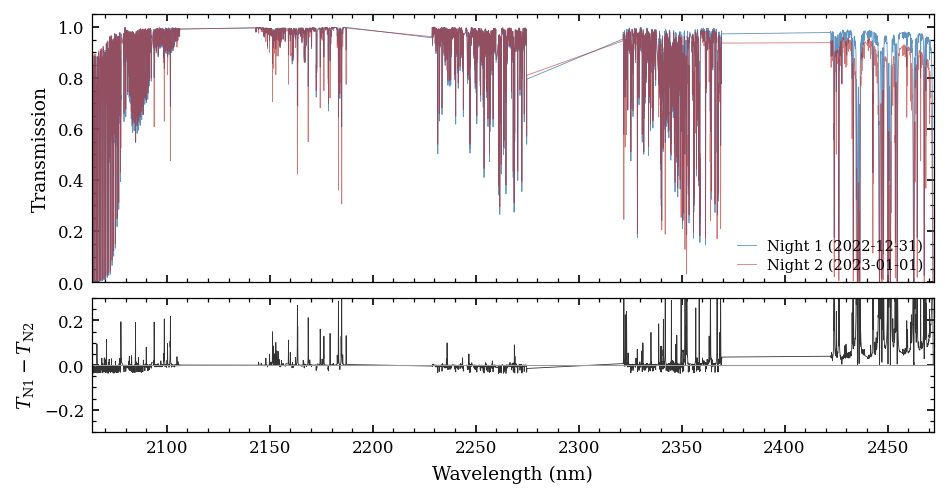

In [7]:
# --- Load the molecfit-fitted telluric transmission template for each night's
#     own chi Tau (telluric standard) observation. Same TELLURIC_DATA.fits
#     product used for the science-frame masking in Figure 1 / cooking_subtraction. ---
tell1 = fits.getdata('/data2/peng/2022-12-31/chi_tau/2022-12-31/out/molecfit/TELLURIC_DATA.fits')
tell2 = fits.getdata('/data2/peng/2023-01-01/chi_tau/2023-01-01/out/molecfit/TELLURIC_DATA.fits')

w1, w2 = tell1['lambda'] * 1e3, tell2['lambda'] * 1e3   # microns -> nm
m1, m2 = tell1['mtrans'], tell2['mtrans']

o1, o2 = np.argsort(w1), np.argsort(w2)
w1, m1 = w1[o1], m1[o1]
w2, m2 = w2[o2], m2[o2]

# molecfit's fitted precipitable water vapor per night -- the real atmospheric
# difference (not just airmass) behind the two templates' disagreement.
par1 = {str(row[0]): row[1] for row in fits.getdata(
    '/data2/peng/2022-12-31/chi_tau/2022-12-31/out/molecfit/BEST_FIT_PARAMETERS.fits', 1)}
par2 = {str(row[0]): row[1] for row in fits.getdata(
    '/data2/peng/2023-01-01/chi_tau/2023-01-01/out/molecfit/BEST_FIT_PARAMETERS.fits', 1)}
print(f"Fitted PWV: Night 1 = {par1['h2o_col_mm']:.3f} mm, Night 2 = {par2['h2o_col_mm']:.3f} mm "
      f"({par2['h2o_col_mm']/par1['h2o_col_mm']:.2f}x more humid on Night 2)")

# Common grid (science range only) for the difference panel
wave_common = np.linspace(2063.7, 2472.4, 20_000)
m1_c = np.interp(wave_common, w1, m1)
m2_c = np.interp(wave_common, w2, m2)

fig, (ax, ax_diff) = plt.subplots(
    2, 1, figsize=(AA_PAGE_WIDTH, 0.5 * AA_PAGE_WIDTH), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.0], 'hspace': 0.08})

ax.plot(w1, m1, color='steelblue', lw=0.4, alpha=0.85, label='Night 1 (2022-12-31)')
ax.plot(w2, m2, color='firebrick', lw=0.4, alpha=0.6, label='Night 2 (2023-01-01)')
ax.set_ylabel('Transmission')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', frameon=False, handlelength=1.3, borderpad=0.2, labelspacing=0.3)
ax.tick_params(labelbottom=False)

ax_diff.plot(wave_common, m1_c - m2_c, color='0.2', lw=0.4)
ax_diff.axhline(0, color='0.6', lw=0.5)
ax_diff.set_ylabel(r'$T_{\rm N1}-T_{\rm N2}$')
ax_diff.set_xlabel('Wavelength (nm)')
ax_diff.set_ylim(-0.3, 0.3)

ax.set_xlim(2063.7, 2472.4)

fig.tight_layout(pad=0.4)
fig.savefig(f'{FIG_DIR}/fig_telluric_comparison.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_telluric_comparison.png', bbox_inches='tight')
plt.show()

## Figure 4 — CO bandhead fit (job 430784, cloud-free benchmark)

Two-night-combined, per-chip-median-normalised spectrum (`combined_two_nights/`, on the Night-2 pixel grid) against the retrieved model for the newest cloud-free benchmark retrieval, job 430784 (008PM-EQ-MEDNORM-ATOMOPAC, Na+Ca opacity, Guidebook v4.2.5). Spans the K2166 order covering the ¹²CO (v=3→1) and ¹³CO (v=2→0) bandheads (2321–2370 nm) — the feature this wavelength setting was chosen to target (Sect. 2). Same convention as `analysis_4.ipynb`'s `plot_model_vs_data_scatter`: telluric transmission overlaid (green, right axis), deep-telluric/clipped pixels shaded gray, model binned the same way as the data (6 px) for display. Data/model/residual identified in this caption rather than a legend; shaded band in the residual panel marks ±3σ of the residual scatter.

In [17]:
# --- Shared data/model loading + per-order plotting helper for Figures 4-5 ---
rid_bandhead = '430784_N600_ev0.5_Normper_chip_median_PerChipScaleFalse'
dir_bandhead = f'/data2/peng/retrievals/{rid_bandhead}'
night_ref = '2023-01-01'   # combined_two_nights sits on the Night-2 pixel grid

mw = np.load(f'{dir_bandhead}/retrieval_model_wave_N2.npy').flatten().astype(float)
mf = np.load(f'{dir_bandhead}/retrieval_model_flux_N2.npy').flatten().astype(float)
fin = np.isfinite(mw) & np.isfinite(mf)
isort = np.argsort(mw[fin])
mw_s, mf_s = mw[fin][isort], mf[fin][isort]

wave_cube = np.array(fits.getdata(
    f'/data2/peng/{night_ref}/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits', 1))[:, 0:5, :].astype(float)

data = np.load('/data2/peng/combined_two_nights/extracted_spectra_combined_two_nights.npy')
err = np.load('/data2/peng/combined_two_nights/extracted_spectra_combined_two_nights_err.npy')
data_cube = data.reshape(wave_cube.shape).astype(float)
err_cube = err.reshape(wave_cube.shape).astype(float)

# molecfit telluric transmission template (Night 2's own chi Tau standard), same
# product/reshaping used for the masking in Figure 1 and in analysis.py.
_t_raw = np.array(fits.getdata(
    f'/data2/peng/{night_ref}/chi_tau/{night_ref}/out/molecfit/TELLURIC_DATA.fits', 1))
_t = np.reshape(_t_raw, (7, 3, 2048))
_t = np.array([_t[i] for i in range(7)][::-1])
telluric_cube = np.transpose(_t, (1, 0, 2))

WIN = 6   # pixels per display bin, applied identically to data and model


def plot_order_panel(ax, ax_res, order, marker_size=10, line_width=0.6):
    """Data (points) + binned model (line) + residuals for one K2166 order, with
    telluric transmission (twin axis, green) and gray spans over masked
    (deep-telluric/clipped) pixels -- same convention as analysis_4.ipynb's
    plot_model_vs_data_scatter. Both panels' y-limits are set from the order's
    own data (percentile-based / 3sigma-based), since S/N varies a lot chip-to-chip.
    """
    ax_tel = ax.twinx()
    all_f, all_resid = [], []
    for det in range(3):
        w = wave_cube[det, order]
        f = data_cube[det, order]
        e = err_cube[det, order]
        valid = np.isfinite(w) & np.isfinite(f) & np.isfinite(e) & (e > 0)

        # --- gray spans over masked (telluric/clipped) interior gaps ---
        _inv = (~valid) & np.isfinite(w)
        if valid.any():
            _inv[:np.argmax(valid)] = False
            _inv[len(valid) - np.argmax(valid[::-1]):] = False
        if _inv.any():
            _idx = np.where(_inv)[0]
            _splits = np.where(np.diff(_idx) > 1)[0] + 1
            for _grp in np.split(_idx, _splits):
                ax.axvspan(w[_grp[0]], w[_grp[-1]], color='gray', alpha=0.22, lw=0, zorder=0)
                ax_res.axvspan(w[_grp[0]], w[_grp[-1]], color='gray', alpha=0.22, lw=0, zorder=0)

        if valid.sum() < WIN:
            continue
        wv, fv, ev = w[valid], f[valid], e[valid]
        m_unb = np.interp(wv, mw_s, mf_s)

        n_bins = len(fv) // WIN
        sl = slice(0, n_bins * WIN)
        w_bin = wv[sl].reshape(n_bins, WIN).mean(1)
        f_bin = fv[sl].reshape(n_bins, WIN).mean(1)
        e_bin = np.sqrt((ev[sl].reshape(n_bins, WIN) ** 2).mean(1)) / np.sqrt(WIN)
        m_bin = m_unb[sl].reshape(n_bins, WIN).mean(1)   # model binned same as data

        f_med = np.nanmedian(fv)
        m_med = np.nanmedian(m_unb)
        f_n, e_n, m_n = f_bin / f_med, e_bin / f_med, m_bin / m_med
        resid = f_n - m_n
        all_f.append(f_n); all_resid.append(resid)

        ax.errorbar(w_bin, f_n, yerr=e_n, fmt='none', ecolor='0.65', elinewidth=0.6, alpha=0.6, zorder=2)
        ax.scatter(w_bin, f_n, s=marker_size, color='steelblue', alpha=0.85, linewidths=0, zorder=3)
        ax.plot(w_bin, m_n, color='firebrick', lw=line_width, alpha=0.9, zorder=4)

        ax_res.errorbar(w_bin, resid, yerr=e_n, fmt='none', ecolor='0.65', elinewidth=0.5, alpha=0.5, zorder=2)
        ax_res.scatter(w_bin, resid, s=0.8 * marker_size, color='steelblue', alpha=0.85, linewidths=0, zorder=3)

        t_w = telluric_cube[det, order]['lambda'] * 1e3
        t_m = telluric_cube[det, order]['mtrans']
        t_ok = np.isfinite(t_w) & np.isfinite(t_m)
        ax_tel.plot(t_w[t_ok], t_m[t_ok], color='forestgreen', lw=0.6, alpha=0.6, zorder=1)

    f_all = np.concatenate(all_f)
    lo, hi = np.nanpercentile(f_all, [0.5, 99.5])
    pad = 0.2 * (hi - lo)
    ax.set_ylim(lo - pad, hi + pad)

    sigma3 = 3 * np.std(np.concatenate(all_resid))
    ax_res.axhspan(-sigma3, sigma3, color='0.5', alpha=0.15, zorder=0)
    ax_res.set_ylim(-max(1.15 * sigma3, 0.05), max(1.15 * sigma3, 0.05))

    ax.axhline(1.0, color='0.6', lw=0.5, ls='--', alpha=0.6)
    ax_res.axhline(0.0, color='0.6', lw=0.5)
    # Compress the telluric curve into the top ~40% of the panel (in its own,
    # data-independent [0,1] units) so it reads as an overlay rather than
    # colliding with the data points.
    ax_tel.set_ylim(-1.5, 1.05)
    ax_tel.set_yticks([0.0, 0.5, 1.0])   # transmission is physically in [0,1]; no ticks below 0
    ax_tel.tick_params(axis='y', labelcolor='forestgreen')
    return ax_tel

print('setup OK')

setup OK


/var/tmp/peng/ipykernel_1163183/1399026645.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.4)


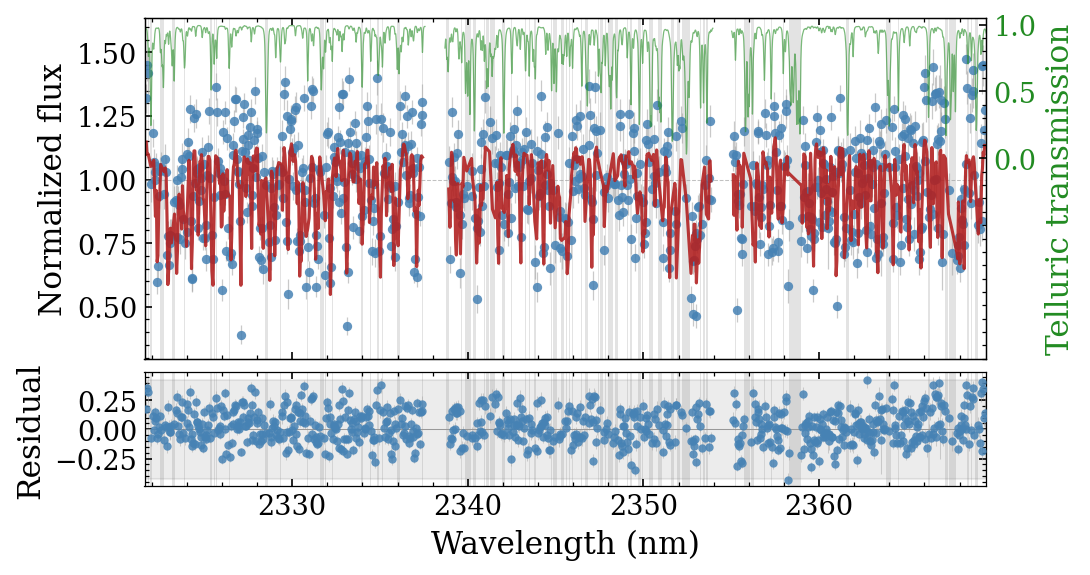

In [18]:
order_bandhead = 1   # native fits order index -> 2321.6-2369.5 nm (12CO + 13CO bandheads)

fig, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(AA_PAGE_WIDTH, 0.56 * AA_PAGE_WIDTH), sharex=True,
    gridspec_kw={'height_ratios': [3.6, 1.2], 'hspace': 0.06})
ax_tel = plot_order_panel(ax, ax_res, order_bandhead, marker_size=20, line_width=1.5)

ax.set_ylabel('Normalized flux', fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.tick_params(labelbottom=False)
ax_tel.set_ylabel('Telluric transmission', fontsize=15, color='forestgreen')
ax_tel.tick_params(axis='y', labelsize=13)

ax_res.set_ylabel('Residual', fontsize=15)
ax_res.set_xlabel('Wavelength (nm)', fontsize=15)
ax_res.tick_params(axis='both', labelsize=13)

ax.set_xlim(np.nanmin(wave_cube[:, order_bandhead, :]), np.nanmax(wave_cube[:, order_bandhead, :]))

fig.tight_layout(pad=0.4)
fig.savefig(f'{FIG_DIR}/fig_co_bandhead.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_co_bandhead.png', bbox_inches='tight')
plt.show()

## Figure 5 — Full K2166 spectrum vs model, all five orders (job 430784)

Same data, model, and plotting convention as Figure 4 (telluric overlay, masked-pixel shading, 6 px-binned data and model, ±3σ residual band, no legend), shown for all five K2166 orders, ordered by wavelength top to bottom. The fourth row is the CO-bandhead order from Figure 4, in context with the rest of the band.

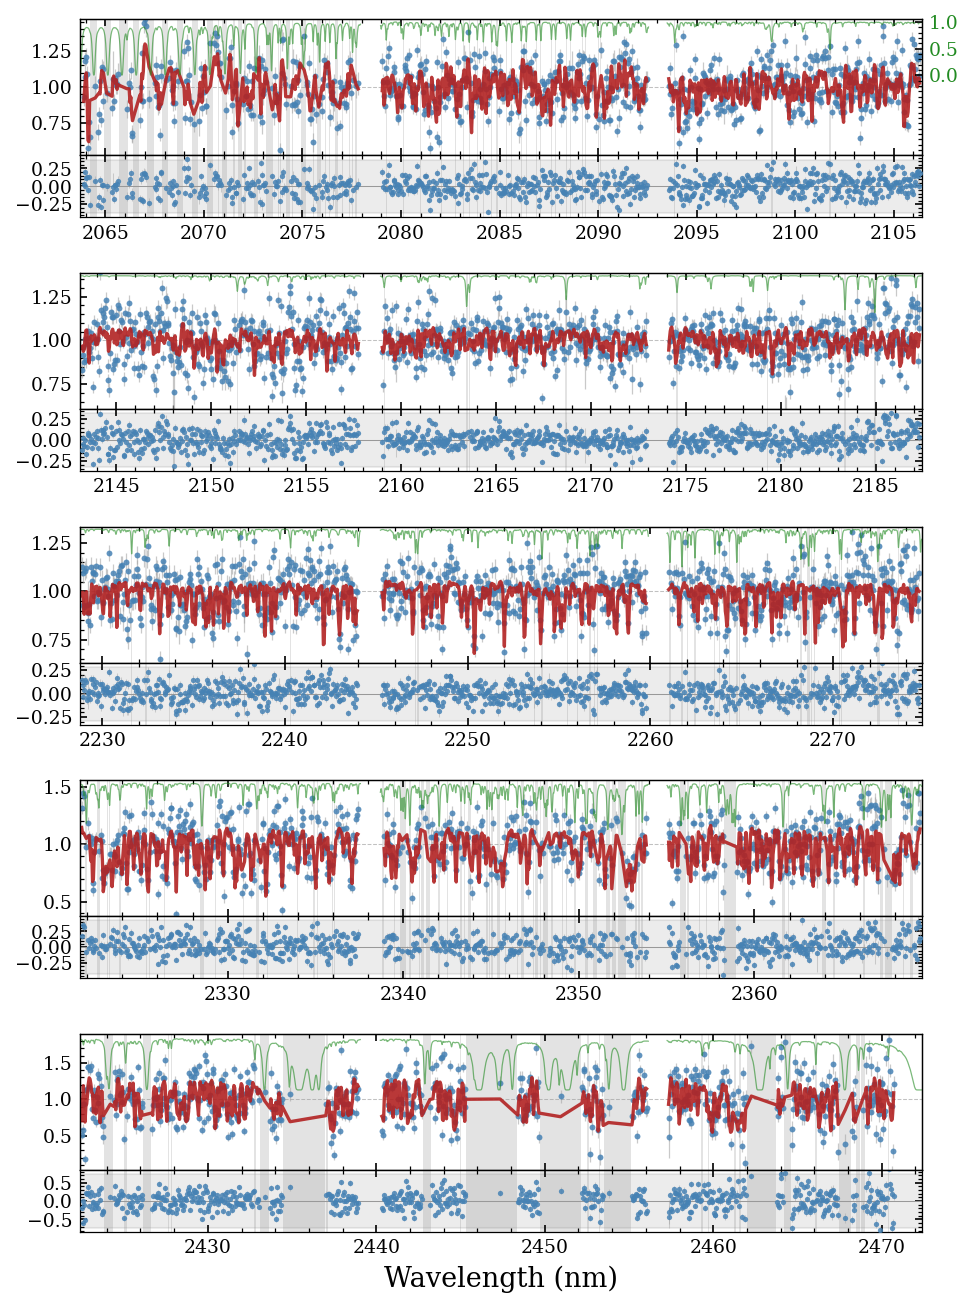

In [8]:
order_list = [4, 3, 2, 1, 0]   # native fits indices, ascending wavelength top to bottom

fig = plt.figure(figsize=(AA_PAGE_WIDTH, 10.5))
gs_outer = fig.add_gridspec(5, 1, hspace=0.28)
for row, order in enumerate(order_list):
    gs_inner = gs_outer[row].subgridspec(2, 1, height_ratios=[2.2, 1.0], hspace=0.0)
    ax = fig.add_subplot(gs_inner[0])
    ax_res = fig.add_subplot(gs_inner[1], sharex=ax)
    ax_tel = plot_order_panel(ax, ax_res, order, marker_size=8, line_width=1.6)

    ax.tick_params(axis='both', labelsize=9)
    ax_res.tick_params(axis='both', labelsize=9)
    ax.tick_params(labelbottom=False)

    if row == 0:
        ax_tel.tick_params(axis='y', labelsize=9)
    else:
        ax_tel.set_yticks([])

    if row == len(order_list) - 1:
        ax_res.set_xlabel('Wavelength (nm)', fontsize=13)

    ax.set_xlim(np.nanmin(wave_cube[:, order, :]), np.nanmax(wave_cube[:, order, :]))

fig.savefig(f'{FIG_DIR}/fig_full_spectrum_all_orders.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_full_spectrum_all_orders.png', bbox_inches='tight')
plt.show()

In [2]:
# --- Shared posterior loading for the fiducial (430784) vs cloud (1001064)
# benchmark comparison figures below ---
import pickle
from pathlib import Path
from scipy.interpolate import PchipInterpolator
import corner

RETRIEVAL_BASE = Path('/data2/peng/retrievals')

def _load_post_and_cols(rid):
    d = RETRIEVAL_BASE / rid
    post = np.load(d / 'final_posterior.npy')
    with open(d / 'final_params_dict.pickle', 'rb') as f:
        pd_ = pickle.load(f)
    non_ret = {'[C/H]', '[C/H]_xsolar', 'phi', 's2', 'chi2', 'phi_N2', 'chi2_N2', 'lnZ'}
    cols = [k for k in pd_ if k not in non_ret][:post.shape[1]]
    return post, {k: i for i, k in enumerate(cols)}, pd_

RID_FID   = '430784_N600_ev0.5_Normper_chip_median_PerChipScaleFalse'
RID_CLOUD = '1001064_N600_ev0.5_Normper_chip_median_PerChipScaleFalse'

post_fid,   idx_fid,   best_fid   = _load_post_and_cols(RID_FID)
post_cloud, idx_cloud, best_cloud = _load_post_and_cols(RID_CLOUD)

COLOR_FID   = 'firebrick'    # matches the model colour in Figs 4-5
COLOR_CLOUD = 'teal'

print(f'Fiducial  (430784, cloud-free): {post_fid.shape[0]} samples x {post_fid.shape[1]} params')
print(f'Cloud     (1001064, cloudy):    {post_cloud.shape[0]} samples x {post_cloud.shape[1]} params')
print('setup OK')


Fiducial  (430784, cloud-free): 4912 samples x 19 params
Cloud     (1001064, cloudy):    4946 samples x 24 params
setup OK


## Figure 6 -- P-T profile: fiducial (cloud-free) vs cloud model, overlapped

In [ ]:
# Two-panel P-T figure: T(P) with Fe/MgSiO3 condensation curves (left,
# Ackerman & Marley 2001 via petitRADTRANS.chemistry.clouds, evaluated at
# the cloud model's retrieved metallicity/C-O) and the temperature
# gradient dlnT/dlnP (right); fiducial vs cloud overlapped.
from petitRADTRANS.chemistry.clouds import return_t_cond_fe_comb, return_t_cond_mgsio3
from petitRADTRANS.chemistry.pre_calculated_chemistry import PreCalculatedEquilibriumChemistryTable

LOG_P_NODES = np.array([0.7, 0.0, -0.3, -0.7, -1.0, -1.5, -3.0, -5.0])
ANCHOR_IDX = 3
PRESSURE = np.logspace(-5, 0.7, 200)
LOG_P_ATM = np.log10(PRESSURE)


def _pt_and_gradient(post, idx):
    n = post.shape[0]
    all_temps = np.empty((n, len(PRESSURE)))
    all_grad = np.empty((n, len(PRESSURE)))
    for i, s in enumerate(post):
        T_anchor = s[idx['T_anchor']]
        dT = np.array([s[idx[f'dT_{j+1}']] for j in range(7)])
        T_nodes = np.empty(8)
        T_nodes[ANCHOR_IDX] = T_anchor
        for j in range(ANCHOR_IDX - 1, -1, -1):
            T_nodes[j] = T_nodes[j + 1] + dT[j]
        for j in range(ANCHOR_IDX + 1, 8):
            T_nodes[j] = T_nodes[j - 1] - dT[j - 1]
        log_P_asc = LOG_P_NODES[::-1]
        T_asc = T_nodes[::-1]
        pchip = PchipInterpolator(log_P_asc, T_asc)
        temp = pchip(LOG_P_ATM)
        temp = np.where(LOG_P_ATM < log_P_asc[0], T_asc[0], temp)
        temp = np.where(LOG_P_ATM > log_P_asc[-1], T_asc[-1], temp)
        temp = np.clip(temp, 1.0, 30000.0)
        all_temps[i] = temp
        dTdlogP = pchip.derivative()(LOG_P_ATM)
        dlnT_dlnP = (dTdlogP / temp) / (1.0 / np.log(10.0))
        all_grad[i] = dlnT_dlnP
    pcts_T = np.percentile(all_temps, [15.87, 50.0, 84.13], axis=0)
    pcts_G = np.percentile(all_grad, [15.87, 50.0, 84.13], axis=0)
    return pcts_T, pcts_G


pcts_T_fid, pcts_G_fid = _pt_and_gradient(post_fid, idx_fid)
pcts_T_cloud, pcts_G_cloud = _pt_and_gradient(post_cloud, idx_cloud)

# --- condensation curves at the cloud model's retrieved metallicity/C-O ---
C_H_cloud = float(np.median(post_cloud[:, idx_cloud['C_H']]))
CO_cloud  = float(np.median(post_cloud[:, idx_cloud['C/O']]))

tbl = PreCalculatedEquilibriumChemistryTable()
tbl.load()
CO_SOLAR = 0.5495
ZH_cloud = C_H_cloud - np.log10(CO_cloud / CO_SOLAR)
_, mmw_arr, _ = tbl.interpolate_mass_fractions(
    co_ratios=CO_cloud * np.ones(10), log10_metallicities=ZH_cloud * np.ones(10),
    temperatures=np.full(10, 1800.0), pressures=np.logspace(-5, 1, 10), full=True)
mmw_cloud = float(np.mean(mmw_arr))

p_fe, t_fe = return_t_cond_fe_comb(C_H_cloud, CO_cloud, mmw_cloud)
p_mg, t_mg = return_t_cond_mgsio3(C_H_cloud, CO_cloud, mmw_cloud)
# restrict to the plotted pressure range for a clean overlay
sel_fe = (p_fe >= 1e-5) & (p_fe <= 10 ** 0.7)
sel_mg = (p_mg >= 1e-5) & (p_mg <= 10 ** 0.7)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(2.05 * AA_COL_WIDTH, 1.35 * AA_COL_WIDTH), sharey=True,
    gridspec_kw={'wspace': 0.08})

for pcts_T, color, label in [
    (pcts_T_fid, COLOR_FID, 'Cloud-free (fiducial)'),
    (pcts_T_cloud, COLOR_CLOUD, 'Cloudy'),
]:
    ax1.fill_betweenx(PRESSURE, pcts_T[0], pcts_T[2], color=color, alpha=0.25, linewidth=0)
    ax1.plot(pcts_T[1], PRESSURE, color=color, lw=1.4, label=label)

ax1.plot(t_fe[sel_fe], p_fe[sel_fe], color='0.35', lw=1.0, ls='--', label='Fe condensation')
ax1.plot(t_mg[sel_mg], p_mg[sel_mg], color='0.35', lw=1.0, ls=':', label=r'MgSiO$_3$ condensation')

ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Pressure (bar)')
ax1.legend(fontsize=6.5, loc='upper right', frameon=False)
ax1.grid(alpha=0.15, lw=0.4)

for pcts_G, color in [(pcts_G_fid, COLOR_FID), (pcts_G_cloud, COLOR_CLOUD)]:
    ax2.fill_betweenx(PRESSURE, pcts_G[0], pcts_G[2], color=color, alpha=0.25, linewidth=0)
    ax2.plot(pcts_G[1], PRESSURE, color=color, lw=1.4)

ax2.axvline(0, color='0.6', lw=0.5, ls='--')
ax2.set_xlabel(r'$\mathrm{d}\ln T / \mathrm{d}\ln P$')
ax2.grid(alpha=0.15, lw=0.4)

ax1.set_xlim(right=max(pcts_T_fid[2].max(), pcts_T_cloud[2].max(), t_fe[sel_fe].max() if sel_fe.any() else 0) * 1.03)
ax1.set_ylim(1e-5, 10 ** 0.7)
ax1.set_yscale('log')
ax1.invert_yaxis()

fig.savefig(f'{FIG_DIR}/fig_pt_profile.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_pt_profile.png', bbox_inches='tight')


## Figure 7 -- Key posterior parameters: fiducial vs cloud model, overlapped

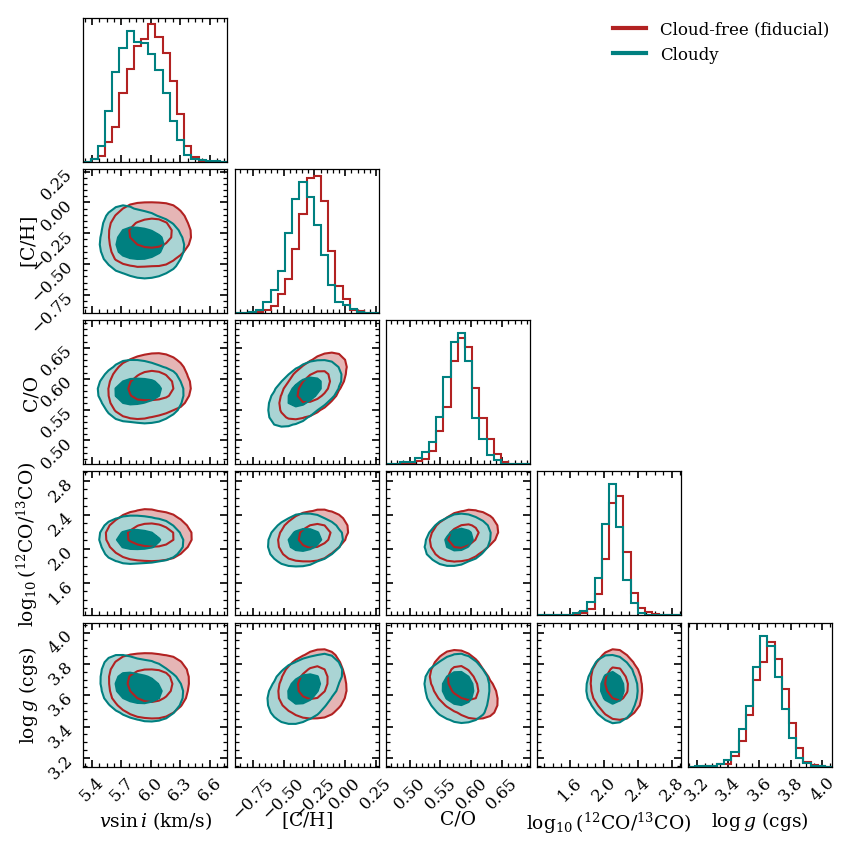

In [4]:
# Compact corner plot of the parameters central to the science case
# (kinematics + bulk composition), fiducial and cloud posteriors overlaid.
# Full corner plots (all free parameters, fiducial only) are in the appendix.
KEY_PARAMS = ['vsini', 'C_H', 'C/O', 'log_12CO_13CO', 'log_g']
KEY_LABELS = [r'$v\sin i$ (km/s)', r'$[{\rm C/H}]$', r'C/O',
              r'$\log_{10}(^{12}{\rm CO}/^{13}{\rm CO})$', r'$\log g$ (cgs)']

samples_fid   = np.column_stack([post_fid[:, idx_fid[k]] for k in KEY_PARAMS])
samples_cloud = np.column_stack([post_cloud[:, idx_cloud[k]] for k in KEY_PARAMS])

_range = []
for j in range(len(KEY_PARAMS)):
    lo = min(samples_fid[:, j].min(), samples_cloud[:, j].min())
    hi = max(samples_fid[:, j].max(), samples_cloud[:, j].max())
    pad = 0.06 * (hi - lo)
    _range.append((lo - pad, hi + pad))

fig = corner.corner(
    samples_fid, labels=KEY_LABELS, range=_range,
    color=COLOR_FID, plot_datapoints=False, fill_contours=True,
    levels=(0.393, 0.865), smooth=1.0, hist_kwargs={'density': True},
    label_kwargs={'fontsize': 9}, title_kwargs={'fontsize': 8},
)
corner.corner(
    samples_cloud, range=_range,
    color=COLOR_CLOUD, plot_datapoints=False, fill_contours=True,
    levels=(0.393, 0.865), smooth=1.0, hist_kwargs={'density': True},
    fig=fig,
)
fig.set_size_inches(AA_COL_WIDTH * 1.6, AA_COL_WIDTH * 1.6)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color=COLOR_FID, lw=2, label='Cloud-free (fiducial)'),
    Line2D([0], [0], color=COLOR_CLOUD, lw=2, label='Cloudy'),
]
fig.legend(handles=legend_elems, loc='upper right', fontsize=8, frameon=False,
           bbox_to_anchor=(0.98, 0.98))

fig.savefig(f'{FIG_DIR}/fig_corner_key.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_corner_key.png', bbox_inches='tight')
plt.show()


## Figure A.2 -- Full posterior corner plot (fiducial model, job 430784)

In [ ]:
# Full free-parameter corner plot for the fiducial (cloud-free) benchmark,
# for the appendix. Cloud-model-only parameters do not apply here (19 params).
ALL_PARAMS_FID = ['rv_N1', 'rv_N2', 'vsini', 'epsilon',
                   'T_anchor', 'dT_1', 'dT_2', 'dT_3', 'dT_4', 'dT_5', 'dT_6', 'dT_7',
                   'C_H', 'C/O', 'log_12CO_13CO', 'F_H',
                   'log_g', 'log_a', 'log_l']
ALL_LABELS_FID = [r'$v_{\rm rad,N1}$', r'$v_{\rm rad,N2}$', r'$v\sin i$', r'$\epsilon_{\rm LD}$',
                   r'$T_{\rm anchor}$', r'$\Delta T_1$', r'$\Delta T_2$', r'$\Delta T_3$',
                   r'$\Delta T_4$', r'$\Delta T_5$', r'$\Delta T_6$', r'$\Delta T_7$',
                   r'$[{\rm C/H}]$', r'C/O', r'$\log(^{12}{\rm CO}/^{13}{\rm CO})$', r'$[{\rm F/H}]$',
                   r'$\log g$', r'$\log a_{\rm GP}$', r'$\log l_{\rm GP}$']

samples_full_fid = np.column_stack([post_fid[:, idx_fid[k]] for k in ALL_PARAMS_FID])

fig = corner.corner(
    samples_full_fid, labels=ALL_LABELS_FID,
    color=COLOR_FID, plot_datapoints=False, fill_contours=True,
    levels=(0.393, 0.865), smooth=1.0, hist_kwargs={'density': True},
    label_kwargs={'fontsize': 11}, title_kwargs={'fontsize': 9},
    show_titles=True, title_fmt='.2f',
    max_n_ticks=3, labelpad=0.10,
)
fig.set_size_inches(1.9 * AA_PAGE_WIDTH, 1.9 * AA_PAGE_WIDTH)
for axis in fig.get_axes():
    axis.tick_params(labelsize=8)
    for label in axis.get_xticklabels():
        label.set_rotation(45)
    for label in axis.get_yticklabels():
        label.set_rotation(0)

fig.savefig(f'{FIG_DIR}/fig_corner_full.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_corner_full.png', bbox_inches='tight')
plt.show()


## Figure 8 -- Cross-correlation functions of key species (H2O, 12CO, 13CO)

CCF normalised by the standard deviation of its wings (|rv|>400 km/s), S/N annotated at the companion's rest-frame velocity (rv=0), not at the CCF's own peak -- appropriate since several species' CCF peaks are noise features far from rv=0 (see the SNR-at-peak vs SNR-at-0 table printed below).

In [2]:
import pickle
from matplotlib.ticker import MaxNLocator

PICKLE = '/data2/peng/Recipe_DH_Tau_B/Reminisce/ccf_results/ccf_430784_results.pickle'  # permanent copy (was: another session's /var/tmp scratchpad, not durable)
with open(PICKLE, 'rb') as f:
    data = pickle.load(f)
rvlag = data['rvlag']
i0 = int(np.argmin(np.abs(rvlag)))
by_label = {v['label']: v for v in data['ccf_results'].values()}


def _panel(ax, res, show_ylabel):
    ccf = res['ccf']
    std_n = res['std_noise']
    ccf_norm = ccf / std_n if (std_n and std_n > 0) else ccf
    snr_at_0 = ccf_norm[i0]
    ax.plot(rvlag, ccf_norm, color='firebrick', lw=0.8)
    ax.axhline(3, color='0.5', lw=0.6, ls='--')
    ax.axhline(-3, color='0.5', lw=0.6, ls='--')
    ax.axhline(0, color='0.75', lw=0.4)
    ax.axvline(0.0, color='k', ls=':', lw=0.8, alpha=0.6)
    ax.set_xlim(-500, 500)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.text(0.03, 0.92, res['label'], transform=ax.transAxes, fontsize=8,
             ha='left', va='top', fontweight='bold')
    ax.text(0.97, 0.92, f'S/N={snr_at_0:.1f}', transform=ax.transAxes, fontsize=7,
             ha='right', va='top')
    ax.set_xlabel('RV lag (km s$^{-1}$)')
    if show_ylabel:
        ax.set_ylabel('CCF / $\\sigma$')


# --- Figure: key species (main text) ---
key_species = ['H2O', '12CO', '13CO']
fig, axes = plt.subplots(1, 3, figsize=(AA_PAGE_WIDTH, 0.32 * AA_PAGE_WIDTH), sharey=False)
for ax, label in zip(axes, key_species):
    _panel(ax, by_label[label], show_ylabel=(label == key_species[0]))
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_ccf_key.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_ccf_key.pdf', bbox_inches='tight')
print('Saved fig_ccf_key.png/pdf')
plt.close(fig)

# --- Figure: remaining species (appendix) ---
other_species = ['CH4', 'FeH', 'HF', 'Na', 'Ca']
fig2, axes2 = plt.subplots(2, 3, figsize=(AA_PAGE_WIDTH, 0.6 * AA_PAGE_WIDTH), sharey=False)
axes2_flat = axes2.flatten()
for i, label in enumerate(other_species):
    _panel(axes2_flat[i], by_label[label], show_ylabel=(i % 3 == 0))
axes2_flat[-1].axis('off')
fig2.tight_layout()
fig2.savefig(f'{FIG_DIR}/fig_ccf_all.png', bbox_inches='tight')
fig2.savefig(f'{FIG_DIR}/fig_ccf_all.pdf', bbox_inches='tight')
print('Saved fig_ccf_all.png/pdf')
plt.close(fig2)

print()
print(f"{'species':8s} {'peak_snr':>9s} {'snr_at_0':>9s}")
for label, res in by_label.items():
    ccf_norm = res['ccf']/res['std_noise']
    print(f"{label:8s} {res['snr']:9.2f} {ccf_norm[i0]:9.2f}")


Saved fig_ccf_key.png/pdf


Saved fig_ccf_all.png/pdf

species   peak_snr  snr_at_0
H2O          34.58     34.58
12CO         17.23     17.23
13CO          4.29      2.41
CH4           2.85     -1.43
FeH           2.85      0.27
HF            4.33      1.37
Na            4.22      2.18
Ca            3.04      1.90
totalCO      17.35     17.35


## Figure 9 -- Carbon isotope ratio ($^{12}$CO/$^{13}$CO) vs. projected separation

Isolated brown dwarfs (no physical separation to plot) are shown in a
narrow categorical strip on the left; bound companions are plotted against
projected separation (au) on a log x-axis on the right, sharing the
12CO/13CO y-axis. Data live in
`/data2/peng/paper/aa/figures/isotope_comparison_data.csv` rather than a
hard-coded list, so targets/separations (with references) can be updated
in one place.

**2026-09-01**: expanded the literature sample substantially -- read
Xuan et al. (2024, ApJ 970:71) directly (no new targets beyond what was
already plotted; its own retrievals cover only GQ Lup b, HIP 79098 b, DH
Tau b), all ten published ESO SupJup Survey papers (I-X), and ran a
broader literature/web search for other high-resolution CO-isotopologue
measurements. Net result: isolated BD sample grew from 5 to 19 targets
(added 2M1425, 2MASS J0835/J0501/J0500 from SupJup VI, Luhman 16A/B from
SupJup IX, six SupJup XI dwarfs (one of six, 2MASS J0953, excluded --
paper itself flags it as not corroborated by the 13CO CCF), 2MASSI
J0443+0002 from Liu et al. 2026, TWA 27A (calibrated value) from Gonzalez
Picos et al. 2025, and 2MASS J0415-0935 from Hood et al. 2024); 2M0355 was
updated in place from Zhang et al. (2021b, Keck/NIRSPEC) to the newer,
higher-resolution Grasser et al. (2025, CRIRES+) value -- the two agree
well so only the more precise one is plotted, unlike the GQ Lup
b/YSES 1 b/DH Tau b cases below where disagreeing values are both shown.
Bound companions grew from 10 to 15 unique targets: added AB Pic b
(SupJup V), ROXs 12 B (SupJup X; its independent, <3sigma, no-error-bar
KPIC value from Xuan et al. 2024 was *not* plotted, for the same reason
the other non-significant KPIC posteriors in that paper aren't), 2MASS
J0249-0557 c from Liu et al. 2026, beta Pic b from Gonzalez Picos et al.
2026 (CRIRES+; a second, independent GRAVITY+ measurement exists -- von
Stauffenberg et al. 2026, 91+24/-17 -- but was left out of the plot at
the user's request, since it's consistent with the CRIRES+ value within
~1sigma and GRAVITY+'s much lower spectral resolution makes it a weaker
comparison point), and HD 19467 B from Gonzalez Picos et al. 2026. Excluded as
unreliable/not-fit-for-purpose after checking the source papers directly:
TWA 5 B (authors call their own ~4 value "unphysical", <3sigma
non-detection), WISE 1828 (lower limit only, not a point measurement),
WASP-77 Ab (a hot Jupiter at 0.024 au -- different formation/detection
regime and off the au-scale x-axis entirely, only ever appeared as an
eyeballed point in a Xuan et al. 2024 literature-compilation figure).

Because the isolated-BD count nearly quadrupled and the separation axis
now needs to span 10-2000 au (was 13-550 au) instead of the original
13-550 au, the panel width ratio, separation-axis limits/ticks, and the
top-axis label staggering were all revised; staggering close top-axis
labels is now computed automatically (cluster consecutive bound targets
within 0.10 dex in separation, offset each by an extra 13 pt) rather than
hand-listed per pair, since which pairs are close changed with the bigger
sample. The overall source canvas was also widened (7.24x5.0in ->
12.3x6.2in) with all font/marker sizes left in points and the
`\includegraphics` width in the .tex unchanged, so the printed figure size
is the same as before but everything on it renders proportionally
smaller/denser to fit the ~3x higher target count.


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

AA_PAGE_WIDTH = 7.24
COLOR_FID = 'firebrick'
COLOR_ISOLATED = '#2a78d6'
COLOR_BOUND = '#eb6834'

FIG_DIR = '/data2/peng/Recipe_DH_Tau_B/Reminisce/paper_figures'
DATA_CSV = '/data2/peng/paper/aa/figures/isotope_comparison_data.csv'

df = pd.read_csv(DATA_CSV)

iso = df[df['category'] == 'isolated'].reset_index(drop=True)
bnd = df[df['category'] == 'bound'].reset_index(drop=True)

# --- two panels sharing the y-axis: a narrow categorical strip for isolated
# brown dwarfs (no separation exists for them) + a wide log-AU axis for
# bound companions, with a broken-axis look between them. Canvas rendered
# ~1.7x wider than a normal AA_PAGE_WIDTH figure (fonts/markers stay fixed
# in points) so the ~19 isolated BDs and ~13 bound companions (up from 5/8)
# have room without overlapping top-axis name labels; the doc-side
# \includegraphics width stays the same, so this only shrinks the effective
# on-page font/marker size and buys layout room, it doesn't change the
# printed figure size. ---
FIG_W, FIG_H = 12.3, 6.2
fig, (ax_iso, ax_sep) = plt.subplots(
    1, 2, figsize=(FIG_W, FIG_H), sharey=True,
    gridspec_kw={'width_ratios': [2.5, 4.2], 'wspace': 0.05})

ism_val, ism_err = 68, 15
sol_val = 89.3
for ax in (ax_iso, ax_sep):
    ax.axhspan(ism_val - ism_err, ism_val + ism_err, color='0.88', zorder=0, lw=0)
    ax.axhline(ism_val, color='0.5', ls=':', lw=0.9, zorder=1)
    ax.axhline(sol_val, color='0.3', ls='--', lw=0.9, zorder=1)
ax_iso.text(0.03, ism_val - 3, 'ISM', color='0.4', fontsize=7, ha='left', va='top',
            transform=ax_iso.get_yaxis_transform())
ax_iso.text(0.03, sol_val + 4, 'Solar', color='0.25', fontsize=7, ha='left', va='bottom',
            transform=ax_iso.get_yaxis_transform())

# --- Left panel: isolated brown dwarfs, no separation axis (categorical, unlabeled) ---
iso_x = np.arange(len(iso)) * 1.4
for i, row in iso.iterrows():
    ax_iso.errorbar(iso_x[i], row['isotope_ratio_12CO_13CO'],
                     yerr=[[row['err_lo']], [row['err_hi']]], fmt='o',
                     markerfacecolor=COLOR_ISOLATED, markeredgecolor=COLOR_ISOLATED,
                     ecolor=COLOR_ISOLATED, markersize=5.5, markeredgewidth=0.9,
                     elinewidth=0.8, capsize=1.8, capthick=0.8, zorder=3)

ax_iso.set_xlim(iso_x.min() - 0.8, iso_x.max() + 0.8)
ax_iso.set_xticks([])
ax_iso.set_xlabel('Isolated BDs\n(no separation)', fontsize=7)
ax_iso.spines['right'].set_visible(False)

# target names as tick labels on a twin axis along the *top* margin, clear
# of all data/error bars, instead of in-plot annotations
top_iso = ax_iso.secondary_xaxis('top')
top_iso.set_xticks(iso_x)
top_iso.set_xticklabels(iso['target'], rotation=80, ha='left', rotation_mode='anchor',
                         fontsize=6.5, color='0.15')
top_iso.tick_params(length=3, pad=2)

# --- Right panel: bound companions, isotope ratio vs projected separation (AU) ---
by_target = {}
for i, row in bnd.iterrows():
    by_target.setdefault(row['target'], []).append(row)

for t, rows in by_target.items():
    xs = [r['separation_au'] for r in rows]
    ys = [r['isotope_ratio_12CO_13CO'] for r in rows]
    if len(rows) == 2:
        ax_sep.plot(xs, ys, color='0.65', lw=0.7, zorder=2)
    for r in rows:
        color = COLOR_BOUND
        if r['highlight_this_work']:
            marker, ms = '*', 12
            mfc = mec = COLOR_FID
        else:
            marker, ms = 'o', 5.5
            mfc = color if r['adopted'] else 'white'
            mec = color
        xerr = None
        if not np.isnan(r['separation_err_lo_au']):
            xerr = [[r['separation_err_lo_au']], [r['separation_err_hi_au']]]
        ax_sep.errorbar(r['separation_au'], r['isotope_ratio_12CO_13CO'],
                         yerr=[[r['err_lo']], [r['err_hi']]], xerr=xerr, fmt=marker,
                         markerfacecolor=mfc, markeredgecolor=mec, ecolor=mec,
                         markersize=ms, markeredgewidth=0.9, elinewidth=0.8,
                         capsize=1.8, capthick=0.8, zorder=3)

ax_sep.set_xscale('log')
ax_sep.set_xlim(2400, 8)
ax_sep.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax_sep.xaxis.set_minor_formatter(mticker.NullFormatter())
ax_sep.set_xticks([10, 20, 30, 50, 100, 200, 300, 500, 1000, 2000])
ax_sep.set_xlabel('Projected separation (au)')
ax_sep.spines['left'].set_visible(False)
ax_sep.tick_params(axis='y', left=False)

# target names as tick labels on a twin axis along the top margin (mirrors
# the isolated-BD panel) rather than in-plot annotations, which crowded the
# data/error bars when separations placed points close together in x. Built
# only after the log scale/limits are set, since changing the parent scale
# afterwards resets a secondary axis's own tick locator.
target_x = {t: rows[0]['separation_au'] for t, rows in by_target.items()}
target_x = dict(sorted(target_x.items(), key=lambda kv: kv[1]))
top_sep = ax_sep.secondary_xaxis('top')
top_sep.set_xticks(list(target_x.values()))
top_sep.set_xticklabels(list(target_x.keys()), rotation=80, ha='left', rotation_mode='anchor',
                         fontsize=6.5, color='0.15')
top_sep.xaxis.set_minor_locator(mticker.NullLocator())
top_sep.tick_params(length=3, pad=2)

# Labels within ~0.1 dex (~25%) of their neighbor in log-separation collide
# at the default pad once rotated 80 deg, so stagger every other label in
# such a run progressively further from the axis. Clusters are found
# automatically (rather than hand-listed) since the sample now spans 13
# bound companions instead of the original 8, with several new close pairs.
names_sorted = list(target_x.keys())
seps_sorted = np.array(list(target_x.values()))
log_seps = np.log10(seps_sorted)
stagger_up = {}
cluster_start = 0
for i in range(1, len(log_seps) + 1):
    if i == len(log_seps) or (log_seps[i] - log_seps[i - 1]) > 0.10:
        cluster = names_sorted[cluster_start:i]
        for j, name in enumerate(cluster):
            if j > 0:
                stagger_up[name] = 13 * j
        cluster_start = i
for name, label in zip(target_x.keys(), top_sep.get_xticklabels()):
    if name in stagger_up:
        label.set_transform(label.get_transform()
                             + mtransforms.ScaledTranslation(0, stagger_up[name] / 72, fig.dpi_scale_trans))

ax_iso.set_yscale('log')
ax_iso.set_ylim(15, 260)
ax_iso.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_iso.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_iso.set_yticks([20, 30, 50, 70, 100, 150, 200])
ax_iso.set_ylabel(r'$^{12}\mathrm{CO}/^{13}\mathrm{CO}$')

# break marks between the two panels
d = 0.02
kwargs = dict(transform=fig.transFigure, color='k', clip_on=False, lw=0.7)
bbox_iso = ax_iso.get_position()
bbox_sep = ax_sep.get_position()
xb = (bbox_iso.x1 + bbox_sep.x0) / 2
for y0 in (bbox_iso.y0, bbox_iso.y1):
    fig.add_artist(plt.Line2D([xb - d, xb + d], [y0 - d, y0 + d], **kwargs))

legend_elems = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR_ISOLATED,
           markeredgecolor=COLOR_ISOLATED, markersize=6, label='Isolated brown dwarfs'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR_BOUND,
           markeredgecolor=COLOR_BOUND, markersize=6, label='Bound companions'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white',
           markeredgecolor='0.3', markersize=6, label='Superseded / other-instrument value'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor=COLOR_FID,
           markeredgecolor=COLOR_FID, markersize=12, label='DH Tau b (this work)'),
]
ax_sep.legend(handles=legend_elems, loc='upper right', frameon=False, ncol=1,
              handletextpad=0.3, borderaxespad=0.3, fontsize=7.5)

fig.savefig(f'{FIG_DIR}/fig_isotope_comparison.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_isotope_comparison.png', bbox_inches='tight', dpi=200)
print('saved to', FIG_DIR)
print('n isolated:', len(iso), 'n bound rows:', len(bnd), 'n bound targets:', len(by_target))
